# Using Linear Regression to Predict Abalone Snail Ages

In this notebook, we use linear regression to predict the ages of abalone snails using their physical measurements as predictor variables. The [Abalone dataset](https://archive.ics.uci.edu/dataset/1/abalone) comes from UC Irvine's Machine Learning Repository.

Abalones are marine snails harvested along the California coastline. According to the dataset information summary, determining their age traditionally requires cutting the shell, staining it, and counting the number of rings under a microscope. This process is tedious and harmful to the snails, as their shells are part of their bodies and vital for their protection.

The Abalone dataset contains physical measurements (length, diameter, height, and several weights) collected on 4,177 snails, along with their ring count, which is a direct proxy for age (approximate age = rings + 1.5 years).

The goal here is to train a Linear Regression model to predict the number of rings from the continuous physical features. If our model is fits well, this could replace what would otherwise be a labour-intensive measurement task.

**Features (after one-hot encoding the sex variable):**
| **Feature** | **Type** | **Description** |
|---|---|---|
| Length | Continuous | Longest shell measurement (mm) |
| Diameter | Continuous | Perpendicular to length (mm) |
| Height | Continuous | Height with meat in shell (mm) |
| Whole weight | Continuous | Whole abalone weight (g) |
| Shucked weight | Continuous | Weight of meat (g) |
| Viscera weight | Continuous | Gut weight after bleeding (g) |
| Shell weight | Continuous | Shell weight after being dried (g) |
| Sex_F / Sex_I / Sex_M | Categorical | One-hot encoded sex (female, infant, male) |

**Target:** Rings (integer, 1–29)


## Load and Explore Data

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from ml_package import (
    LinearRegression, 
    StandardScaler, 
    train_test_split,
    regression_metrics
)

np.random.seed(42)

In [24]:
df = pd.read_csv("abalone.data", header = None)

# Name columns
columns = [
    "Sex", "Length", "Diameter", "Height", "WholeWeight",
    "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings"
]

df = pd.read_csv("abalone.data", names=columns)

df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [25]:
# Assign features and target
X = df.drop(columns=['Rings'])
y = df["Rings"]

# Descriptive statistics
print(X.describe().round(3))
print(f"\nTarget (Rings)  —  mean: {y.mean():.2f}, std: {y.std():.2f}, range: [{y.min()}, {y.max()}]")

         Length  Diameter    Height  WholeWeight  ShuckedWeight  \
count  4177.000  4177.000  4177.000     4177.000       4177.000   
mean      0.524     0.408     0.140        0.829          0.359   
std       0.120     0.099     0.042        0.490          0.222   
min       0.075     0.055     0.000        0.002          0.001   
25%       0.450     0.350     0.115        0.442          0.186   
50%       0.545     0.425     0.140        0.800          0.336   
75%       0.615     0.480     0.165        1.153          0.502   
max       0.815     0.650     1.130        2.826          1.488   

       VisceraWeight  ShellWeight  
count       4177.000     4177.000  
mean           0.181        0.239  
std            0.110        0.139  
min            0.000        0.002  
25%            0.094        0.130  
50%            0.171        0.234  
75%            0.253        0.329  
max            0.760        1.005  

Target (Rings)  —  mean: 9.93, std: 3.22, range: [1, 29]


---

Below, we create a histogram showing the distribution of the target variable (number of rings) and a heatmap displaying the correlations between features.

---

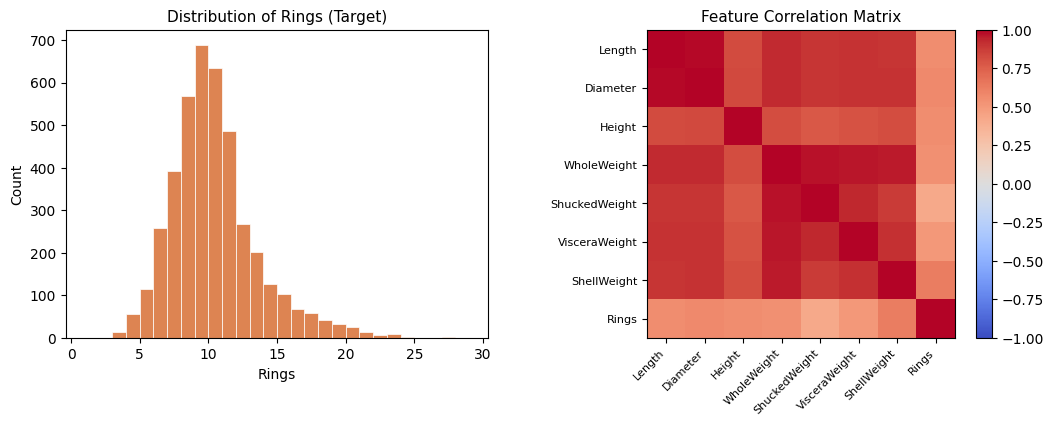


Correlation with Rings:
ShellWeight      0.628
Diameter         0.575
Height           0.557
Length           0.557
WholeWeight      0.540
VisceraWeight    0.504
ShuckedWeight    0.421


In [29]:
# Rings distribution + correlation heat-map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Rings histogram
ax1.hist(y, bins=28, color="#DD8452", edgecolor="white", linewidth=0.5)
ax1.set_title("Distribution of Rings (Target)", fontsize=11)
ax1.set_xlabel("Rings"); ax1.set_ylabel("Count")

# Correlation matrix
X_numeric = X.select_dtypes(include=[np.number]).copy()
X_numeric["Rings"] = y
corr = X_numeric.corr()
im = ax2.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr))); ax2.set_yticks(range(len(corr)))
ax2.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title("Feature Correlation Matrix", fontsize=11)

plt.show()
print("\nCorrelation with Rings:")
print(corr["Rings"].drop("Rings").sort_values(ascending=False).round(3).to_string())


---

The correlation heatmap shows that shell weight and diameter correlate most strongly with the number of rings (about 0.63 and 0.58, respectively), implying that these may be the most informative predictors for our model. The heatmap also shows that the four weight features are highly intercorrelated, suggesting that there is multicollinearity present in our feature data that could impact the results. Linear regression can handle this, but the redundant information may inflate coefficient variances.

---

## Data Preprocessing

We one-hot encode the categorical Sex feature, then apply StandardScaler so gradient descent converges smoothly. Standardization is important for gradient-descent-based linear regression because it ensures all features have comparable gradient magnitudes, preventing a single large-scale feature from dominating the weight updates.

---

In [31]:
# One-hot encode 'Sex'
X_enc = pd.get_dummies(X, columns=["Sex"], drop_first=False).astype(float)
X_arr = X_enc.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Train: 3341 samples  |  Test: 836 samples


## Train the Linear Regression Model

Next, we train the linear regression model on the scaled feature data, setting the learning rate equal to 0.01 and the number of epochs equal to 2000. At each epoch, the model computes predictions by multiplying the weights and inputs, then adding the bias. The model then calculates MSE loss and updates the weights according to the computed gradient.

---

In [32]:
# Define and train the linear regression model

model = LinearRegression()
model.train(X_train_s, y_train, eta=0.01, epochs=2000)
print(f"Final training MSE: {model.losses[-1]:.4f}")


Final training MSE: 4.8123


---

The graph below plots the MSE losses against the epoch number, using a log-scale on the y-axis. The curve shows a steep descent in the first few hundred epochs followed by a flattening plateau, indicating convergence.

---

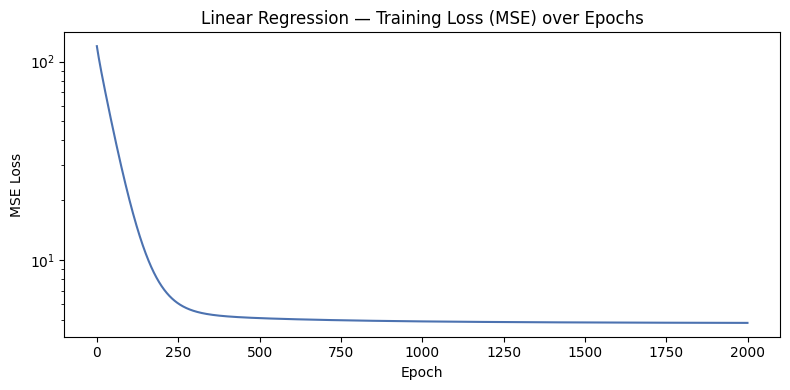

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(model.losses, color="#4C72B0", linewidth=1.5)
plt.title("Linear Regression — Training Loss (MSE) over Epochs", fontsize=12)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.yscale("log")
plt.tight_layout()
plt.show()


## Evaluation

Now that we have trained our model, it's time to evaluate it's performance on the test set. For informational purposes (not neccessarily required in practice), we use the full suite of evaluation methods included in the `LinearRegression` class.

---

In [1]:
y_pred_train = model.predict(X_train_s)
y_pred_test  = model.predict(X_test_s)

print(f"  RMSE   :       {model.rmse(X_test_s, y_test):.4f}")
print(f"  MAE    :       {model.mae(X_test_s, y_test):.4f}")
print(f"  MAPE   :       {model.mape(X_test_s, y_test):.2f}%")
print(f"  R^2    :       {model.r_squared(X_test_s, y_test):.4f}")
print(f"  R^2 adj:       {model.r_squared_adj(X_test_s, y_test):.4f}")
print(f"  AIC    :       {model.aic(X_test_s, y_test):.2f}")
print(f"  BIC    :       {model.bic(X_test_s, y_test):.2f}")

NameError: name 'model' is not defined

---

Our model returns an R-squared value of 0.49, which implies that 49% of the total variation in the number of ring rings can be explained by the feature data. A plot of the data with both the fitted regression and the true unknown regression line is shown below.

---

C:\Users\Owinf\AppData\Local\Temp\ipykernel_3676\543469954.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_range, x_range, "r--", alpha=0.5, label="Perfect Fit (y=x)", color = "blue")


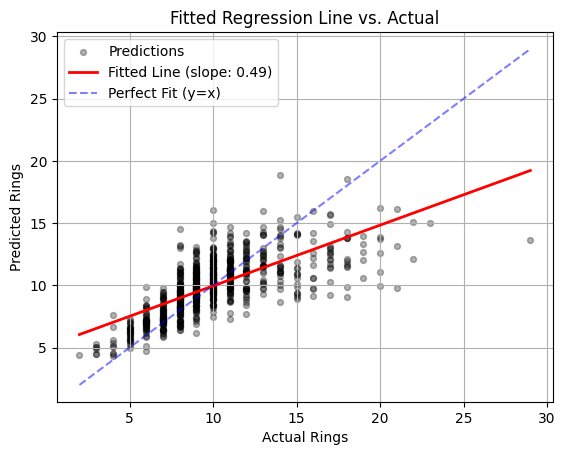

In [47]:
# Scatter plot of the data
plt.scatter(y_test, y_pred_test, alpha=0.3, s=18, color="black", label="Predictions")

# 2. Calculate the FITTED regression line (y = mx + b)
m, b = np.polyfit(y_test, y_pred_test, 1)
x_range = np.array([y_test.min(), y_test.max()])
plt.plot(x_range, m * x_range + b, color="red", linewidth=2, label=f"Fitted Line (slope: {m:.2f})")

# Reference: true unknown regression line
plt.plot(x_range, x_range, "r--", alpha=0.5, label="Perfect Fit (y=x)", color = "blue")

# Formatting
plt.title("Fitted Regression Line vs. Actual", fontsize=12)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.grid(zorder = 1)
plt.legend()
plt.show()

---

We can also see which features were most important in predicting the number of rings. Because we standardized the features, the model weights are directly comparable — the larger absolute weight, the more influence on the predicted ring count.

---

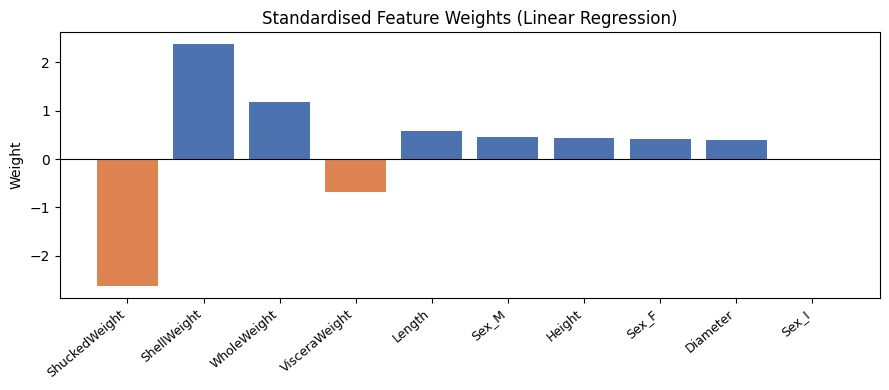

In [48]:
feat_names = list(X_enc.columns)
weights = model.weights

order = np.argsort(np.abs(weights))[::-1]
colors = ["#4C72B0" if w > 0 else "#DD8452" for w in weights[order]]

plt.figure(figsize=(9, 4))
plt.bar(range(len(feat_names)), weights[order], color=colors)
plt.xticks(range(len(feat_names)), [feat_names[i] for i in order], rotation=40, ha="right", fontsize=9)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Standardised Feature Weights (Linear Regression)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


---

From this graph, we can see that shucked weight and shell weight had the highest absolute weights.


Overall, because rings are a count variable with natural discretisation, a linear model is inherently limited here. Tree-based or non-linear methods (see the other notebooks) tend to improve performance.

---